In [2]:
%load_ext autoreload
%autoreload 2

In [12]:
# Add the `src` directory to sys.path for local imports if the script is run directly
import sys
import numpy as np
if not __package__:
    sys.path.insert(0, '/home/mike/git/QDMpy/src')

In [4]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from QDMpy.odmr.data import ODMRData
from QDMpy.odmr.io import MatlabLoader
from QDMpy.odmr.processors import BinningProcessor
from QDMpy.odmr.odmr import ODMR
from QDMpy.fit import Fit


11:53:22     INFO QDMpy.<module> >> WELCOME TO QDMpy
11:53:22    DEBUG QDMpy.<module> >> QDMpy version 0.1.0a installed at /home/mike/git/QDMpy/src/QDMpy
11:53:22    DEBUG QDMpy.<module> >> QDMpy config file /home/mike/.config/QDMpy/config.ini
11:53:22     INFO QDMpy.load_config >> Loading config file: /home/mike/.config/QDMpy/config.ini
0 <class 'ctypes.c_ulong'>
1 <class 'ctypes.c_ulong'>
2 <class 'pygpufit.gpufit.LP_c_float'>
3 <class 'pygpufit.gpufit.LP_c_float'>
4 <class 'ctypes.c_int'>
5 <class 'pygpufit.gpufit.LP_c_float'>
6 <class 'pygpufit.gpufit.LP_c_float'>
7 <class 'pygpufit.gpufit.LP_c_int'>
8 <class 'ctypes.c_float'>
9 <class 'ctypes.c_int'>
10 <class 'pygpufit.gpufit.LP_c_int'>
11 <class 'ctypes.c_int'>
12 <class 'ctypes.c_ulong'>
13 <class 'ctypes.LP_c_char'>
14 <class 'pygpufit.gpufit.LP_c_float'>
15 <class 'pygpufit.gpufit.LP_c_int'>
16 <class 'pygpufit.gpufit.LP_c_float'>
17 <class 'pygpufit.gpufit.LP_c_int'>
11:53:22     INFO QDMpy.<module> >> CUDA available: True
1

In [6]:

# User-friendly initialization
loader = MatlabLoader(data_folder="/home/mike/git/QDMpy/tests/data")
odmr_data = ODMRData.from_loader(loader=loader)
odmr = ODMR(odmr_data)
odmr.processor_manager.add_processor(BinningProcessor(bin_factor=2))
odmr.process_data()

11:53:22     INFO QDMpy.odmr.data.from_loader >> Loading ODMR data using loader: MatlabLoader
11:53:23    DEBUG QDMpy.odmr.processors.add_processor >> Adding processor: BinningProcessor
11:53:23     INFO QDMpy.odmr.odmr.process_data >> Processing data.
11:53:23     INFO QDMpy.odmr.processors.process >> Starting processing pipeline.
11:53:23    DEBUG QDMpy.odmr.processors.process >> Applying processor: BinningProcessor
11:53:23    DEBUG QDMpy.odmr.processors.process >> Binning data with factor: 2
11:53:23     INFO QDMpy.odmr.processors.process >> Processing pipeline completed.


In [7]:
from QDMpy.fit import Fit
from QDMpy import guess

11:53:23     INFO QDMpy.models.register >> Registered model: ESR14N
11:53:23     INFO QDMpy.models.register >> Registered model: ESR15N
11:53:23     INFO QDMpy.models.register >> Registered model: ESRSINGLE


In [8]:
from QDMpy.models import ModelRegistry

In [25]:
n_peaks, doubt, _ = guess.guess_n_peaks(odmr.processed_data.data)

In [26]:
guess.get_model_by_peaks(n_peaks)

'ESR15N'

In [14]:
from scipy.signal import find_peaks

In [15]:
median_data = np.median(odmr.processed_data.data, axis=3)

In [22]:
find_peaks(-median_data[0,0], prominence=0.000004)

(array([ 8, 17]),
 {'prominences': array([0.00301266, 0.00316977]),
  'left_bases': array([0, 0]),
  'right_bases': array([12, 24])})

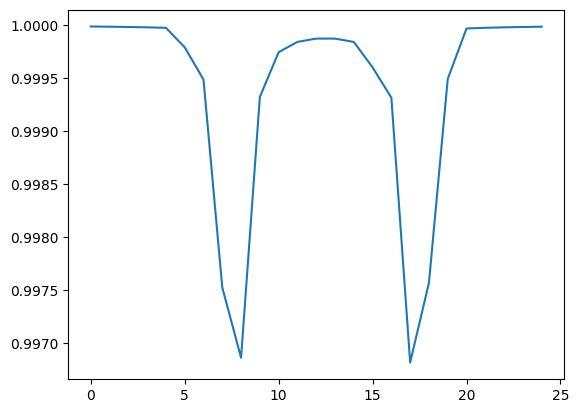

In [21]:
plt.plot(median_data[0,0])
plt.show()
# print(fit)

In [17]:
import numpy as np
np.median(odmr.processed_data.data, axis=3).shape

(2, 2, 25)

In [19]:
models.guess_model_name(odmr.processed_data.data)

11:02:44     INFO QDMpy._core.models.guess_model_name >> Guessed diamond type: 2 peaks -> ESR15N (N15)


'ESR15N'

In [21]:
fit = Fit(odmr)

11:04:23     INFO QDMpy.fit.__init__ >> Initializing Fit instance.
11:04:23     INFO QDMpy._core.models.guess_model_name >> Guessed diamond type: 2 peaks -> ESR15N (N15)


In [36]:
models.IMPLEMENTED[fit.model_name]

{'func_name': 'ESR15N',
 'n_peaks': 2,
 'func': <function QDMpy._core.models.esr15n(x, parameter)>,
 'params': ['center', 'width', 'contrast', 'contrast', 'offset'],
 'model_id': 14,
 'name': 'N15'}

In [28]:
models.

11:07:15     INFO QDMpy.fit.fit_odmr >> Fitting frequency range 0: 2840000000.0-2840000000.0 GHz


AttributeError: 'Fit' object has no attribute 'initial_parameter'

In [32]:
from __future__ import annotations

In [42]:
guess_initial_fit_parameters(odmr.processed_data.data, odmr.processed_data.frequencies, models.IMPLEMENTED[fit.model_name]).shape

(2, 2, 25, 5)

In [40]:
from QDMpy.initial_guess import *

In [33]:
def guess_initial_fit_parameters(
    data: NDArray, freq: NDArray, model: Dict[str, Any]
) -> NDArray:
    """
    Guess initial fit parameters based on the selected model.

    :param data: NDArray
        3D array of the data to fit (e.g., ODMR data).
    :param freq: NDArray
        1D array of the frequencies corresponding to the data.
    :param model: Dict[str, Any]
        Model dictionary containing parameter names and number of peaks.

    :return: NDArray
        Initial fit parameters as a 4D array of shape (n_pol, n_frange, n_pixel, n_params).
    """
    # Define parameter guessers for each parameter type
    parameter_guessers = {
        "center": lambda: guess_center(data, freq),
        "contrast": lambda: guess_contrast(data),
        "width": lambda: guess_width(
            data, freq, vmin=0.3, vmax=0.7
        ),  # Default vmin/vmax can be adjusted dynamically
        "offset": lambda: np.ones(data.shape[:-1]),  # Offset is often assumed to be 1
    }

    # Initialize list for parameter arrays
    fit_parameters = []

    # Guess each parameter defined in the model
    for param in model["params"]:
        if param in parameter_guessers:
            fit_parameters.append(parameter_guessers[param]())
        else:
            raise ValueError(f"Parameter {param} has no defined guess method.")

    # Stack parameters along the last axis
    return np.stack(fit_parameters, axis=-1)
